# Predicting Large Breaches — XGBoost + SHAP

**Question:** when a breach is first reported, can we predict from the structured fields alone
whether it will turn out to be *large* (10,000+ individuals — roughly the worst third of breaches)?

**Leakage discipline:** features are restricted to what exists *at report time* — entity type,
breach type, location of breached information, business-associate involvement, state, and
submission date. Narrative-derived features (attack vector, remediation) are deliberately
excluded: OCR writes narratives only after a case closes, so using them would leak the future.

**Honest expectation:** these are coarse categorical fields, so this is a partial-signal problem.
The value is in *which* factors move risk (SHAP), not in a headline accuracy number.

In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.metrics import (RocCurveDisplay, classification_report,
                             roc_auc_score)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
LARGE = 10_000  # threshold for a "large" breach

df = pd.read_csv("../data/breach_clean.csv")
df["Individuals Affected"] = pd.to_numeric(df["Individuals Affected"], errors="coerce")
df = df.dropna(subset=["Individuals Affected", "Covered Entity Type",
                       "Type of Breach", "State"]).reset_index(drop=True)
df["Primary Breach Type"] = df["Type of Breach"].str.split(",").str[0].str.strip()
df["Primary Location"] = df["Location of Breached Information"].str.split(",").str[0].str.strip()
df["Month"] = pd.to_datetime(df["Breach Submission Date"]).dt.month

y = (df["Individuals Affected"] >= LARGE).astype(int)
X = pd.get_dummies(df[["Covered Entity Type", "Primary Breach Type", "Primary Location",
                       "Business Associate Present", "State"]])
X["Year"] = df["Year"]
X["Month"] = df["Month"]
FEATURES = list(X.columns)
print(f"{len(df):,} breaches | target base rate (>= {LARGE:,} affected): {y.mean():.1%} | {len(FEATURES)} features")

7,764 breaches | target base rate (>= 10,000 affected): 34.4% | 75 features


/sessions/busy-keen-albattani/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Train and evaluate — two splits

A random stratified split answers "how well does this generalize within the same era?";
a temporal split (train < 2023, test 2023+) answers the harder, more realistic question —
"can a model trained on the past predict the future?" Both are reported.

In [2]:
params = dict(n_estimators=300, max_depth=4, learning_rate=0.08, subsample=0.9,
              colsample_bytree=0.8, eval_metric="auc", random_state=RANDOM_STATE)

# random stratified split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y,
                                          random_state=RANDOM_STATE)
model = xgb.XGBClassifier(**params).fit(X_tr, y_tr)
proba = model.predict_proba(X_te)[:, 1]
auc_random = roc_auc_score(y_te, proba)

# temporal split
past, future = df["Year"] < 2023, df["Year"] >= 2023
model_t = xgb.XGBClassifier(**params).fit(X[past], y[past])
auc_temporal = roc_auc_score(y[future], model_t.predict_proba(X[future])[:, 1])

print(f"AUC random split:   {auc_random:.3f}")
print(f"AUC temporal split: {auc_temporal:.3f}  (train <2023: {past.sum():,} | test 2023+: {future.sum():,})")
print()
print(classification_report(y_te, (proba >= 0.5).astype(int),
                            target_names=["<10k affected", ">=10k affected"]))

AUC random split:   0.731
AUC temporal split: 0.667  (train <2023: 5,139 | test 2023+: 2,625)

                precision    recall  f1-score   support

 <10k affected       0.75      0.84      0.79      1018
>=10k affected       0.61      0.47      0.53       535

      accuracy                           0.71      1553
     macro avg       0.68      0.65      0.66      1553
  weighted avg       0.70      0.71      0.70      1553



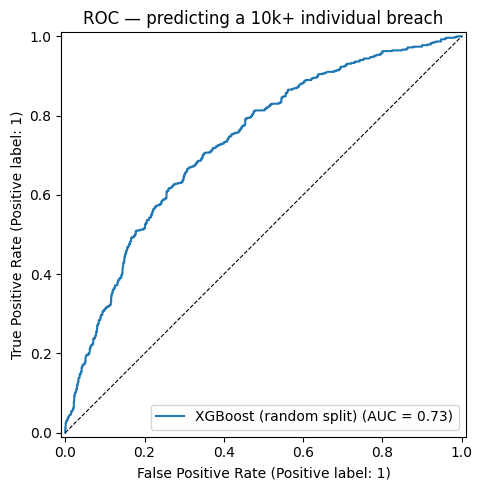

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 5))
RocCurveDisplay.from_predictions(y_te, proba, name="XGBoost (random split)", ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("ROC — predicting a 10k+ individual breach")
plt.tight_layout(); plt.show()

**Reading the numbers honestly:** AUC ~0.73 on a random split and ~0.67 on the temporal split.
That is meaningfully better than chance (0.5) but far from deterministic — the structured report
fields carry real but partial signal about eventual breach size. The temporal drop reflects the
shifting threat landscape: models trained on the pre-2023 mix underestimate the modern
hacking-dominated regime. That, itself, is a finding.

## 2. Why the model predicts what it predicts — SHAP

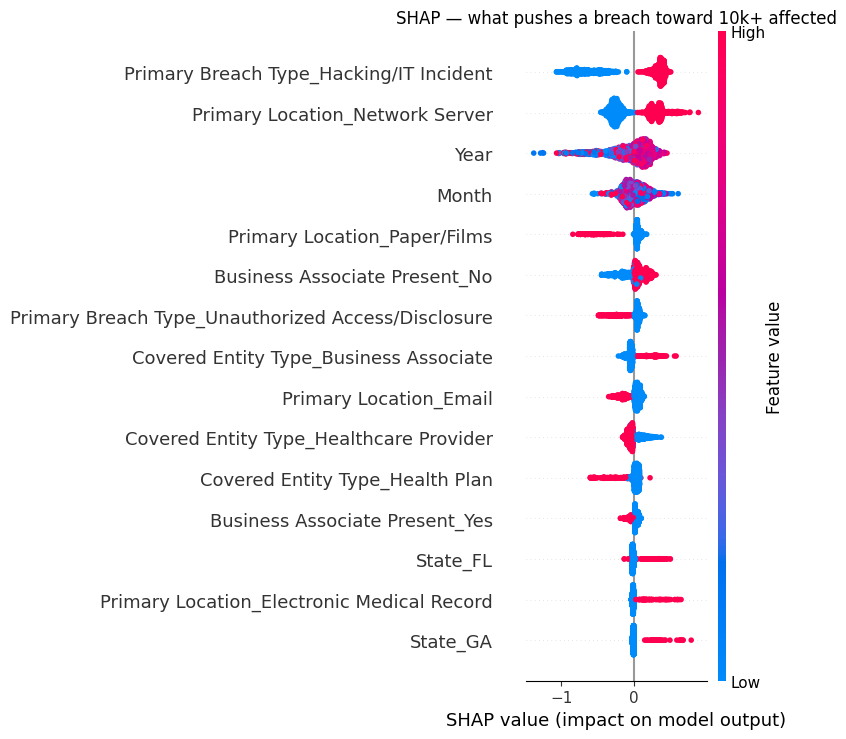

In [4]:
# SHAP values via XGBoost's built-in TreeSHAP (robust across xgboost/shap versions)
dmat = xgb.DMatrix(X_te, feature_names=FEATURES)
contribs = model.get_booster().predict(dmat, pred_contribs=True)
shap_values = contribs[:, :-1]  # last column is the bias term

shap.summary_plot(shap_values, X_te, max_display=15, show=False)
plt.title("SHAP — what pushes a breach toward 10k+ affected")
plt.tight_layout(); plt.show()

In [5]:
importance = (pd.DataFrame({"feature": FEATURES,
                            "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
              .sort_values("mean_abs_shap", ascending=False))
importance.head(12)

,feature,mean_abs_shap
4,Primary Breach Type_Hacking/IT Incident,0.470655
15,Primary Location_Network Server,0.282807
73,Year,0.208188
74,Month,0.116947
18,Primary Location_Paper/Films,0.104758
19,Business Associate Present_No,0.101078
9,Primary Breach Type_Unauthorized Access/Disclo...,0.095006
0,Covered Entity Type_Business Associate,0.084541
13,Primary Location_Email,0.070651
3,Covered Entity Type_Healthcare Provider,0.069886


The drivers are consistent with the EDA: **hacking/IT incident** and **network-server
location** push predictions up hardest; **paper/films** and **unauthorized access/disclosure**
push down; **business-associate involvement** and later **submission years** raise risk.
Nothing exotic — but now quantified per-breach and per-feature rather than eyeballed.

## 3. Persist model artifacts

In [6]:
joblib.dump(model, "../models/xgb_severity.joblib")
with open("../models/xgb_feature_columns.json", "w") as f:
    json.dump(FEATURES, f, indent=2)
importance.to_csv("../models/shap_importance.csv", index=False)
print("saved: models/xgb_severity.joblib, models/xgb_feature_columns.json, models/shap_importance.csv")

saved: models/xgb_severity.joblib, models/xgb_feature_columns.json, models/shap_importance.csv
